<a href="https://colab.research.google.com/github/israellimon-tt/cohorte108b-sprint7-practica/blob/main/Sprint07_W22_Practica%20(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sprint 7 · Clase práctica comprimida v2 · Proyecto guiado con automatización básica

**Duración:** 0 - 120 minutos  
**Modalidad:** Práctica guiada  
**Nivel:** Introductorio  

Esta práctica consolida los temas de preparación de datos, exploración, gráficos, outliers, segmentación y GitHub. La diferencia principal frente a la versión anterior es que ahora se incluye explícitamente **automatización con iterables, ciclos `for`, ciclos `while` y mini-funciones**.


## Fecha

Completa la información de la sesión:

- **Fecha:**  
- **Instructor/a:**  Israel Limon
- **Duración:** 0 - 120 minutos


## Objetivos de la sesión práctica

Al finalizar la sesión, la persona estudiante podrá:

1. Crear un dataset sintético de ventas multicanal.
2. Explorar estructura, tipos de datos y valores nulos.
3. Limpiar valores nulos con reglas simples.
4. Usar listas como iterables para automatizar tareas con `for`.
5. Usar un ciclo `while` con contador para recorrer columnas.
6. Crear mini-funciones para resumir, limpiar y clasificar datos.
7. Detectar outliers con IQR.
8. Crear segmentos de negocio con `.apply()`.
9. Proponer una estructura básica para publicar el análisis en GitHub.


## Metodología de la sesión

Trabajaremos como analistas de una tienda multicanal que vende productos en varios países de Latinoamérica.

El negocio quiere responder preguntas como:

- ¿Qué países y categorías generan más ingresos?
- ¿Qué canales tienen mejores márgenes?
- ¿Hay ventas atípicas?
- ¿Qué segmentos de ventas existen?
- ¿Cómo podemos automatizar revisiones repetitivas?


## Ejercicio 0

Caso: una tienda multicanal vende productos por Web, App, tienda física y WhatsApp. Tiene operaciones en Colombia, México, Perú y Chile.

Responde:

1. ¿Qué variable usarías para medir el tamaño de una venta?
2. ¿Qué variable usarías para medir rentabilidad?
3. ¿Qué columnas podrían tener valores nulos?
4. ¿Qué tareas te gustaría automatizar para no repetir código?


## Proyecto práctico: “Ventas Multicanal LATAM”

Usaremos un dataset sintético con 120 ventas. No es un dataset perfecto: tendrá nulos y outliers para practicar.

### Columnas principales

| Columna | Descripción |
|---|---|
| `venta_id` | Identificador de venta |
| `fecha` | Fecha de venta |
| `pais`, `ciudad` | Ubicación |
| `canal` | Web, App, tienda física o WhatsApp |
| `categoria` | Categoría de producto |
| `metodo_pago` | Método de pago |
| `tipo_cliente` | Nuevo o recurrente |
| `ingreso` | Venta después de descuentos |
| `costo_total` | Costo estimado |
| `margen` | Ingreso menos costo |
| `edad_cliente` | Edad del cliente |
| `satisfaccion` | Calificación de 1 a 5 |
| `dias_entrega` | Días de entrega |
| `devolucion` | Sí o No |


## Preparación del entorno y creación del dataset

Ejecuta esta celda antes de iniciar los ejercicios.


In [1]:
# ============================================================
# Dataset sintético: ventas multicanal
# ============================================================
# Este dataset se crea dentro del notebook para no depender de archivos externos.
# Cada fila representa una venta realizada por un cliente.

import pandas as pd
import random
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Fijamos una semilla para que todos obtengan los mismos datos.
random.seed(7)

paises = ['Colombia', 'México', 'Perú', 'Chile']
ciudades_por_pais = {
    'Colombia': ['Cali', 'Bogotá', 'Medellín', 'Barranquilla'],
    'México': ['CDMX', 'Guadalajara', 'Monterrey', 'Puebla'],
    'Perú': ['Lima', 'Arequipa', 'Cusco', 'Trujillo'],
    'Chile': ['Santiago', 'Valparaíso', 'Concepción', 'La Serena']
}
canales = ['Web', 'App', 'Tienda física', 'WhatsApp']
categorias = ['Tecnología', 'Hogar', 'Ropa', 'Belleza', 'Deportes']
metodos_pago = ['Tarjeta', 'Transferencia', 'Efectivo', 'Billetera digital']
tipos_cliente = ['Nuevo', 'Recurrente']

ventas = []

for venta_id in range(1, 121):
    pais = random.choice(paises)
    ciudad = random.choice(ciudades_por_pais[pais])
    categoria = random.choice(categorias)
    canal = random.choice(canales)
    metodo_pago = random.choice(metodos_pago)
    tipo_cliente = random.choice(tipos_cliente)

    unidades = random.randint(1, 5)
    precio_unitario = random.choice([25000, 40000, 55000, 80000, 120000, 180000, 250000])
    descuento_pct = random.choice([0, 0.05, 0.10, 0.15, 0.20])

    ingreso = unidades * precio_unitario * (1 - descuento_pct)
    costo_total = ingreso * random.choice([0.45, 0.55, 0.65, 0.75])
    margen = ingreso - costo_total

    satisfaccion = random.choice([1, 2, 3, 4, 5, None])
    edad_cliente = random.choice([19, 22, 25, 28, 31, 35, 39, 42, 47, 52, 58, None])
    dias_entrega = random.choice([1, 2, 3, 4, 5, 6, 7, 10, None])
    devolucion = random.choice(['Sí', 'No', 'No', 'No', 'No'])

    ventas.append({
        'venta_id': venta_id,
        'fecha': pd.Timestamp('2026-01-01') + pd.Timedelta(days=random.randint(0, 89)),
        'pais': pais,
        'ciudad': ciudad,
        'canal': canal,
        'categoria': categoria,
        'metodo_pago': metodo_pago,
        'tipo_cliente': tipo_cliente,
        'unidades': unidades,
        'precio_unitario': precio_unitario,
        'descuento_pct': descuento_pct,
        'ingreso': ingreso,
        'costo_total': costo_total,
        'margen': margen,
        'edad_cliente': edad_cliente,
        'satisfaccion': satisfaccion,
        'dias_entrega': dias_entrega,
        'devolucion': devolucion
    })

df = pd.DataFrame(ventas)

# Agregamos algunos casos extremos de forma intencional para practicar outliers.
df.loc[4, 'ingreso'] = 2_800_000
df.loc[4, 'margen'] = 1_250_000
df.loc[18, 'dias_entrega'] = 35
df.loc[50, 'edad_cliente'] = 82
df.loc[90, 'ingreso'] = 1_900_000
df.loc[90, 'margen'] = 850_000

# Guardamos una copia local por si queremos reutilizar el CSV.
# df.to_csv('ventas_multicanal_sprint7_intro.csv', index=False)

print('Dataset creado correctamente')
print('Filas y columnas:', df.shape)
display(df.head())


Dataset creado correctamente
Filas y columnas: (120, 18)


,venta_id,fecha,pais,ciudad,canal,categoria,metodo_pago,tipo_cliente,unidades,precio_unitario,descuento_pct,ingreso,costo_total,margen,edad_cliente,satisfaccion,dias_entrega,devolucion
0,1,2026-01-09,Perú,Arequipa,Web,Belleza,Tarjeta,Nuevo,3,120000,0.00,"360,000.00","198,000.00","162,000.00",22.00,1.00,7.00,No
1,2,2026-01-29,México,CDMX,WhatsApp,Deportes,Tarjeta,Nuevo,2,180000,0.20,"288,000.00","129,600.00","158,400.00",52.00,5.00,7.00,Sí
2,3,2026-01-13,Colombia,Bogotá,WhatsApp,Ropa,Transferencia,Nuevo,5,55000,0.20,"220,000.00","121,000.00","99,000.00",52.00,1.00,4.00,No
3,4,2026-03-31,Colombia,Cali,App,Deportes,Billetera digital,Recurrente,3,80000,0.20,"192,000.00","144,000.00","48,000.00",31.00,3.00,4.00,No
4,5,2026-02-13,México,CDMX,Tienda física,Deportes,Billetera digital,Recurrente,4,55000,0.20,"2,800,000.00","79,200.00","1,250,000.00",47.00,1.00,7.00,No


## Ejercicio 1 · Primer vistazo al dataset

### Tarea

1. Muestra el tamaño del dataset.
2. Muestra las primeras filas.
3. Lista los nombres de las columnas.
4. Revisa los tipos de datos.

### Pista

Usa `.shape`, `.head()`, `.columns` e `.info()`.


In [2]:
# Ejercicio 1

print('Tamaño del dataset:')
print(df.shape)

Tamaño del dataset:
(120, 18)


In [3]:
print('\nPrimeras filas:')
display(df.head())


Primeras filas:


,venta_id,fecha,pais,ciudad,canal,categoria,metodo_pago,tipo_cliente,unidades,precio_unitario,descuento_pct,ingreso,costo_total,margen,edad_cliente,satisfaccion,dias_entrega,devolucion
0,1,2026-01-09,Perú,Arequipa,Web,Belleza,Tarjeta,Nuevo,3,120000,0.00,"360,000.00","198,000.00","162,000.00",22.00,1.00,7.00,No
1,2,2026-01-29,México,CDMX,WhatsApp,Deportes,Tarjeta,Nuevo,2,180000,0.20,"288,000.00","129,600.00","158,400.00",52.00,5.00,7.00,Sí
2,3,2026-01-13,Colombia,Bogotá,WhatsApp,Ropa,Transferencia,Nuevo,5,55000,0.20,"220,000.00","121,000.00","99,000.00",52.00,1.00,4.00,No
3,4,2026-03-31,Colombia,Cali,App,Deportes,Billetera digital,Recurrente,3,80000,0.20,"192,000.00","144,000.00","48,000.00",31.00,3.00,4.00,No
4,5,2026-02-13,México,CDMX,Tienda física,Deportes,Billetera digital,Recurrente,4,55000,0.20,"2,800,000.00","79,200.00","1,250,000.00",47.00,1.00,7.00,No


In [4]:
print('\nColumnas:')
print(df.columns.to_list())


Columnas:
['venta_id', 'fecha', 'pais', 'ciudad', 'canal', 'categoria', 'metodo_pago', 'tipo_cliente', 'unidades', 'precio_unitario', 'descuento_pct', 'ingreso', 'costo_total', 'margen', 'edad_cliente', 'satisfaccion', 'dias_entrega', 'devolucion']


In [5]:
print('\nInformación general:')
df.info()


Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   venta_id         120 non-null    int64         
 1   fecha            120 non-null    datetime64[ns]
 2   pais             120 non-null    object        
 3   ciudad           120 non-null    object        
 4   canal            120 non-null    object        
 5   categoria        120 non-null    object        
 6   metodo_pago      120 non-null    object        
 7   tipo_cliente     120 non-null    object        
 8   unidades         120 non-null    int64         
 9   precio_unitario  120 non-null    int64         
 10  descuento_pct    120 non-null    float64       
 11  ingreso          120 non-null    float64       
 12  costo_total      120 non-null    float64       
 13  margen           120 non-null    float64       
 14  edad_cliente     111

## Ejercicio 2 · Identificar valores nulos

### Tarea

1. Calcula cuántos nulos hay por columna.
2. Identifica las 3 columnas con más nulos.




In [6]:
# Ejercicio 2
nulos_por_columna = df.isna().sum()

print(nulos_por_columna)

venta_id            0
fecha               0
pais                0
ciudad              0
canal               0
categoria           0
metodo_pago         0
tipo_cliente        0
unidades            0
precio_unitario     0
descuento_pct       0
ingreso             0
costo_total         0
margen              0
edad_cliente        9
satisfaccion       21
dias_entrega       12
devolucion          0
dtype: int64


In [7]:
print('\nColumnas con más nulos:')
print(nulos_por_columna.sort_values(ascending=False).head(3))


Columnas con más nulos:
satisfaccion    21
dias_entrega    12
edad_cliente     9
dtype: int64


## Ejercicio 3 · Limpiar nulos con reglas simples

### Tarea

Crea una copia llamada `df_limpio` y completa:

- `edad_cliente` con la mediana.
- `satisfaccion` con la mediana.
- `dias_entrega` con la mediana.

### Pista

Usa `.copy()`, `.median()` y `.fillna()`.


In [8]:
# Ejercicio 3

df_limpio = df.copy()
df_limpio['edad_cliente'] = df_limpio['edad_cliente'].fillna(df_limpio['edad_cliente'].median())
df_limpio['satisfaccion'] = df_limpio['satisfaccion'].fillna(df_limpio['satisfaccion'].median())
df_limpio['dias_entrega'] = df_limpio['dias_entrega'].fillna(df_limpio['dias_entrega'].median())


In [9]:
print('Nulos después de limpiar:')
print(df_limpio.isna().sum())

Nulos después de limpiar:
venta_id           0
fecha              0
pais               0
ciudad             0
canal              0
categoria          0
metodo_pago        0
tipo_cliente       0
unidades           0
precio_unitario    0
descuento_pct      0
ingreso            0
costo_total        0
margen             0
edad_cliente       0
satisfaccion       0
dias_entrega       0
devolucion         0
dtype: int64


## Ejercicio 4 · Automatización con iterables y `for`

Un iterable puede ser una lista de columnas. En este ejercicio, usaremos una lista para revisar varias columnas sin copiar y pegar.

### Tarea

1. Crea una lista con columnas numéricas importantes.
2. Usa un ciclo `for` para imprimir promedio, mínimo y máximo de cada columna.

### Pista

La estructura base es:

```python
for columna in lista_columnas:
    print(df_limpio[columna].mean())
```


In [10]:
# Ejercicio 4

columnas_numericas = ['unidades', 'ingreso', 'costo_total', 'margen', 'edad_cliente', 'satisfaccion', 'dias_entrega']

for columna in columnas_numericas:
  print('Columna:', columna)
  print('Promedio:', round(df_limpio[columna].mean(),2))
  print('Minimo:', df_limpio[columna].min())
  print('Maximo:', df_limpio[columna].max())
  print('-------------------------')


Columna: unidades
Promedio: 3.13
Minimo: 1
Maximo: 5
-------------------------
Columna: ingreso
Promedio: 315306.25
Minimo: 20000.0
Maximo: 2800000.0
-------------------------
Columna: costo_total
Promedio: 167844.27
Minimo: 11250.0
Maximo: 890625.0
-------------------------
Columna: margen
Promedio: 126563.65
Minimo: 5312.5
Maximo: 1250000.0
-------------------------
Columna: edad_cliente
Promedio: 34.52
Minimo: 19.0
Maximo: 82.0
-------------------------
Columna: satisfaccion
Promedio: 2.95
Minimo: 1.0
Maximo: 5.0
-------------------------
Columna: dias_entrega
Promedio: 4.56
Minimo: 1.0
Maximo: 35.0
-------------------------


## Ejercicio 5 · Automatización con `while`

El ciclo `while` se repite mientras una condición sea verdadera.

### Tarea

Usa `while` para recorrer esta lista de columnas:

```python
columnas_revision = ['ingreso', 'margen', 'dias_entrega']
```

En cada vuelta, imprime el nombre de la columna y su promedio.

### Nota:

Siempre actualiza el contador dentro del `while`. Si no lo haces, el ciclo puede quedar infinito.


In [11]:
columnas_revision = ['ingreso', 'margen', 'dias_entrega', 'otro']
len(columnas_revision)

4

In [12]:
# Ejercicio 5

columnas_revision = ['ingreso', 'margen', 'dias_entrega']
indice = 0

while indice < len(columnas_revision):
  columna = columnas_revision[indice]
  promedio = df_limpio[columna].mean()

  print('Columna revisada:', columna)
  print('Promedio:', round(promedio,2))
  print('-------------------------')

  indice = indice + 1


Columna revisada: ingreso
Promedio: 315306.25
-------------------------
Columna revisada: margen
Promedio: 126563.65
-------------------------
Columna revisada: dias_entrega
Promedio: 4.56
-------------------------


## Ejercicio 6 · Mini-función para resumir una columna

Las funciones ayudan a organizar código y reutilizarlo.

### Tarea

Crea una función llamada `resumir_columna()` que reciba:

- una tabla,
- el nombre de una columna.

La función debe imprimir:

- promedio,
- mediana,
- mínimo,
- máximo.


In [26]:
# Ejercicio 6
def resumir_columna(tabla, columna):
  print('Resumen de:', columna)
  print('Promedio:', round(tabla[columna].mean(),2))
  print('Mediana:', round(tabla[columna].median(),2))
  print('Minimo:', tabla[columna].min())
  print('Maximo:', tabla[columna].max())
  print('---------')



In [27]:
nuevas_revision = ['ingreso', 'margen', 'dias_entrega']

for columna in nuevas_revision:
  resumir_columna(df_limpio, columna)

Resumen de: ingreso
Promedio: 315306.25
Mediana: 185000.0
Minimo: 20000.0
Maximo: 2800000.0
---------
Resumen de: margen
Promedio: 126563.65
Mediana: 73400.0
Minimo: 5312.5
Maximo: 1250000.0
---------
Resumen de: dias_entrega
Promedio: 4.56
Mediana: 4.0
Minimo: 1.0
Maximo: 35.0
---------


## Ejercicio 7 · Combinar función + `for`

### Tarea

Usa la función `resumir_columna()` dentro de un ciclo `for` para resumir:

- `ingreso`
- `margen`
- `dias_entrega`

Este patrón es una forma simple de automatización.


In [28]:
# Ejercicio 7

for columna in ['ingreso', 'margen', 'dias_entrega']:
  resumir_columna(df_limpio, columna)



Resumen de: ingreso
Promedio: 315306.25
Mediana: 185000.0
Minimo: 20000.0
Maximo: 2800000.0
---------
Resumen de: margen
Promedio: 126563.65
Mediana: 73400.0
Minimo: 5312.5
Maximo: 1250000.0
---------
Resumen de: dias_entrega
Promedio: 4.56
Mediana: 4.0
Minimo: 1.0
Maximo: 35.0
---------


## Ejercicio 8 · GroupBy para responder preguntas de negocio

### Tarea

Calcula:

1. Ingreso total por país.
2. Margen promedio por canal.
3. Cantidad de ventas por categoría.

### Pista

Usa `groupby()` con una sola columna para mantenerlo simple.


In [30]:
df_limpio.head()

,venta_id,fecha,pais,ciudad,canal,categoria,metodo_pago,tipo_cliente,unidades,precio_unitario,descuento_pct,ingreso,costo_total,margen,edad_cliente,satisfaccion,dias_entrega,devolucion
0,1,2026-01-09,Perú,Arequipa,Web,Belleza,Tarjeta,Nuevo,3,120000,0.00,"360,000.00","198,000.00","162,000.00",22.00,1.00,7.00,No
1,2,2026-01-29,México,CDMX,WhatsApp,Deportes,Tarjeta,Nuevo,2,180000,0.20,"288,000.00","129,600.00","158,400.00",52.00,5.00,7.00,Sí
2,3,2026-01-13,Colombia,Bogotá,WhatsApp,Ropa,Transferencia,Nuevo,5,55000,0.20,"220,000.00","121,000.00","99,000.00",52.00,1.00,4.00,No
3,4,2026-03-31,Colombia,Cali,App,Deportes,Billetera digital,Recurrente,3,80000,0.20,"192,000.00","144,000.00","48,000.00",31.00,3.00,4.00,No
4,5,2026-02-13,México,CDMX,Tienda física,Deportes,Billetera digital,Recurrente,4,55000,0.20,"2,800,000.00","79,200.00","1,250,000.00",47.00,1.00,7.00,No


In [32]:
# Ejercicio 8

print('Ingreso total por país')
display(df_limpio.groupby('pais')['ingreso'].sum())

print('Margen promedio por canal')
display(df_limpio.groupby('canal')['margen'].mean())

print('Cantidad de ventas por categoría')
display(df_limpio.groupby('categoria')['venta_id'].count())



Ingreso total por país


,ingreso
pais,
Chile,"8,542,000.00"
Colombia,"8,933,250.00"
México,"12,127,000.00"
Perú,"8,234,500.00"


Margen promedio por canal


,margen
canal,
App,"127,823.61"
Tienda física,"169,050.43"
Web,"107,765.24"
WhatsApp,"111,436.72"


Cantidad de ventas por categoría


,venta_id
categoria,
Belleza,27
Deportes,24
Hogar,26
Ropa,21
Tecnología,22


## Ejercicio 9 · Gráficos con `.plot()`

### Tarea

1. Crea un gráfico de barras con el ingreso total por país.
2. Crea un histograma de la columna `ingreso`.

### Pista

Usa `.plot(kind='bar')` y `.plot(kind='hist')`.


In [33]:
df_limpio.head()

,venta_id,fecha,pais,ciudad,canal,categoria,metodo_pago,tipo_cliente,unidades,precio_unitario,descuento_pct,ingreso,costo_total,margen,edad_cliente,satisfaccion,dias_entrega,devolucion
0,1,2026-01-09,Perú,Arequipa,Web,Belleza,Tarjeta,Nuevo,3,120000,0.00,"360,000.00","198,000.00","162,000.00",22.00,1.00,7.00,No
1,2,2026-01-29,México,CDMX,WhatsApp,Deportes,Tarjeta,Nuevo,2,180000,0.20,"288,000.00","129,600.00","158,400.00",52.00,5.00,7.00,Sí
2,3,2026-01-13,Colombia,Bogotá,WhatsApp,Ropa,Transferencia,Nuevo,5,55000,0.20,"220,000.00","121,000.00","99,000.00",52.00,1.00,4.00,No
3,4,2026-03-31,Colombia,Cali,App,Deportes,Billetera digital,Recurrente,3,80000,0.20,"192,000.00","144,000.00","48,000.00",31.00,3.00,4.00,No
4,5,2026-02-13,México,CDMX,Tienda física,Deportes,Billetera digital,Recurrente,4,55000,0.20,"2,800,000.00","79,200.00","1,250,000.00",47.00,1.00,7.00,No


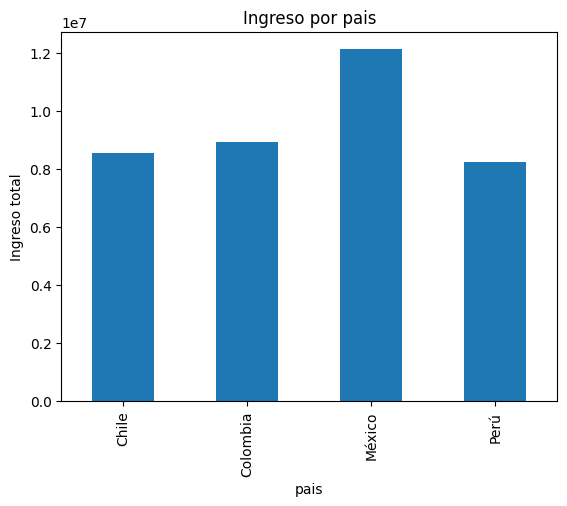

In [34]:
# Ejercicio 9A - el ingreso total por país
ingreso_por_pais = df_limpio.groupby('pais')['ingreso'].sum()

ingreso_por_pais.plot(kind='bar', title='Ingreso por pais')
plt.ylabel('Ingreso total')
plt.show()



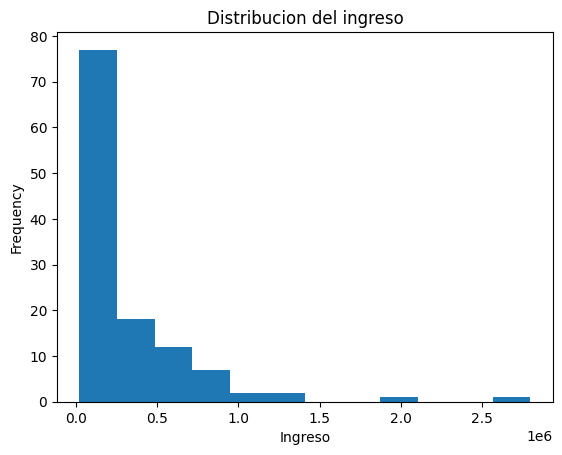

In [35]:
# Ejercicio 9B - histograma de la columna ingreso
df_limpio['ingreso'].plot(kind='hist', bins=12, title='Distribucion del ingreso')
plt.xlabel('Ingreso')
plt.show()




## Ejercicio 10 · Mini-función para detectar outliers con IQR

### Tarea

Crea una función llamada `obtener_limites_iqr()` que reciba:

- una tabla,
- una columna.

La función debe retornar el límite inferior y superior.


In [37]:
# Ejercicio 10

def obtener_limites_iqr(tabla, columna):
  Q1 = tabla[columna].quantile(0.25)
  Q3 = tabla[columna].quantile(0.75)

  iqr = Q3 - Q1

  limite_inferior = Q1 - 1.5 * iqr
  limite_superior = Q3 + 1.5 * iqr

  return limite_inferior, limite_superior


limite_inf, limite_sup = obtener_limites_iqr(df_limpio, 'ingreso')

print('Límite inferior:', limite_inf)
print('Límite superior:', limite_sup)


Límite inferior: -342000.0
Límite superior: 858000.0


## Ejercicio 11 · Filtrar ventas atípicas

### Tarea

Usa los límites del ejercicio anterior para encontrar las ventas cuyo `ingreso` sea mayor al límite superior.


In [38]:
# Ejercicio 11
ventas_atipicas = df_limpio[df_limpio['ingreso'] > limite_sup]

display(ventas_atipicas[['venta_id','pais','canal','ingreso','margen']])



,venta_id,pais,canal,ingreso,margen
4,5,México,Tienda física,"2,800,000.00","1,250,000.00"
46,47,Perú,WhatsApp,"900,000.00","495,000.00"
70,71,México,Web,"950,000.00","237,500.00"
71,72,Colombia,App,"1,187,500.00","296,875.00"
78,79,Chile,App,"1,187,500.00","296,875.00"
89,90,Chile,App,"1,062,500.00","478,125.00"
90,91,Colombia,Tienda física,"1,900,000.00","850,000.00"


## Ejercicio 12 · Segmentación con función + `.apply()`

### Tarea

Crea una función llamada `clasificar_venta()`:

- Si el ingreso es mayor o igual a 500000: `Venta grande`.
- Si el ingreso es mayor o igual a 150000: `Venta media`.
- En otro caso: `Venta pequeña`.

Luego crea una columna llamada `segmento_venta`.


In [42]:
# Ejercicio 12

def clasificar_venta(ingreso):
  if ingreso >= 500000:
    return 'Venta grande'
  elif ingreso >= 150000:
    return 'Venta media'
  else:
    return 'Venta pequeña'

# print(clasificar_venta(50000))

df_limpio['segmento_venta'] = df_limpio['ingreso'].apply(clasificar_venta)

display(df_limpio[['venta_id', 'ingreso', 'segmento_venta']].head(10))


,venta_id,ingreso,segmento_venta
0,1,"360,000.00",Venta media
1,2,"288,000.00",Venta media
2,3,"220,000.00",Venta media
3,4,"192,000.00",Venta media
4,5,"2,800,000.00",Venta grande
5,6,"486,000.00",Venta media
6,7,"648,000.00",Venta grande
7,8,"272,000.00",Venta media
8,9,"152,000.00",Venta media
9,10,"432,000.00",Venta media


## Ejercicio 13 · Automatizar varios resúmenes finales

### Tarea

Crea una función llamada `resumen_por_grupo()` y úsala con un ciclo `for` para generar resúmenes por:

- `pais`
- `canal`
- `categoria`
- `segmento_venta`

Cada resumen debe mostrar:

- cantidad de ventas,
- ingreso total,
- margen promedio.


In [43]:
# Ejercicio 13

def resumen_por_grupo(tabla, grupo):
    resumen = tabla.groupby(grupo).agg({
        'venta_id': 'count',
        'ingreso': 'sum',
        'margen': 'mean'
    })
    return resumen

grupos = ['pais', 'canal', 'categoria', 'segmento_venta']

for grupo in grupos:
    print('Resumen por:', grupo)
    display(resumen_por_grupo(df_limpio, grupo))
    print('-------------------------')


Resumen por: pais


,venta_id,ingreso,margen
pais,,,
Chile,29,"8,542,000.00","114,517.24"
Colombia,25,"8,933,250.00","142,244.50"
México,35,"12,127,000.00","140,296.43"
Perú,31,"8,234,500.00","109,682.26"


-------------------------
Resumen por: canal


,venta_id,ingreso,margen
canal,,,
App,18,"6,814,500.00","127,823.61"
Tienda física,29,"11,212,250.00","169,050.43"
Web,41,"11,188,500.00","107,765.24"
WhatsApp,32,"8,621,500.00","111,436.72"


-------------------------
Resumen por: categoria


,venta_id,ingreso,margen
categoria,,,
Belleza,27,"7,717,000.00","110,987.96"
Deportes,24,"10,682,500.00","162,368.75"
Hogar,26,"7,495,000.00","116,455.77"
Ropa,21,"5,265,250.00","108,410.12"
Tecnología,22,"6,677,000.00","135,893.18"


-------------------------
Resumen por: segmento_venta


,venta_id,ingreso,margen
segmento_venta,,,
Venta grande,22,"20,096,500.00","367,496.59"
Venta media,52,"13,718,250.00","105,085.34"
Venta pequeña,46,"4,022,000.00","35,614.67"


-------------------------


## Ejercicio 14 · Exportar el dataset limpio

Guardar el archivo permite usarlo luego en otro notebook o subirlo a GitHub.


In [44]:
# Ejercicio 14

df_limpio.to_csv('ventas_multicanal_sprint7_limpio.csv', index=False)
print('Archivo exportado: ventas_multicanal_sprint7_limpio.csv')
print('---------------')


Archivo exportado: ventas_multicanal_sprint7_limpio.csv


## Estructura sugerida para GitHub

```text
ventas-multicanal-latam/
├── data/
│   ├── ventas_multicanal_sprint7_intro.csv
│   └── ventas_multicanal_sprint7_limpio.csv
├── notebooks/
│   └── sprint7_analisis_ventas_multicanal.ipynb
├── images/
│   └── graficos_del_analisis.png
└── README.md
```

### README mínimo

```markdown
# Análisis de ventas multicanal LATAM

## Objetivo
Analizar ventas, márgenes, canales, categorías y posibles valores atípicos.

## Dataset
Dataset sintético de 120 ventas creado con Python.

## Herramientas
Python, Pandas y Matplotlib.

## Pasos principales
1. Crear dataset.
2. Explorar datos.
3. Limpiar nulos.
4. Automatizar resúmenes con for, while y funciones.
5. Detectar outliers.
6. Segmentar ventas.
7. Exportar resultados.
```


## Takeaways

- Un análisis inicial no requiere código complejo, pero sí orden.
- Las listas permiten guardar columnas y recorrerlas con ciclos.
- `for` es útil cuando sabemos qué elementos queremos recorrer.
- `while` es útil cuando la repetición depende de una condición.
- Las funciones evitan repetir lógica.
- `groupby()` permite responder preguntas de negocio.
- IQR ayuda a detectar ventas atípicas.
- `.apply()` permite aplicar una función a cada valor de una columna.


## Cierre




## Información complementaria

Para practicar después de clase:

1. Crear una función para clasificar clientes por edad.
2. Crear un gráfico de ingreso por canal.
3. Detectar outliers en `dias_entrega`.
4. Crear un resumen por `metodo_pago`.
5. Cambiar los límites de segmentación de ventas y comparar resultados.
